# classic mini-games: Pong, Snake and Breakout
* lesson 27 gave us all the LEGO bricks of game dev with pygame: drawing shapes/text, the game loop, simulating keyboard input, collision detection with `Rect.colliderect()`, and our `show_surface()` trick to see a pygame surface inline in this notebook
* this lesson uses ALL of those bricks together, for real: we build three complete, tiny, honest-to-god classic games - **Pong**, **Snake** and **Breakout** - the same three games basically every game-dev tutorial in the world starts you off with
* we still cant take live keyboard input inside a notebook (no real screen/keyboard attached, remember?), so instead every game here is driven by a **scripted/simple-AI sequence of moves** we run for a fixed number of frames - a paddle that just follows the ball, a hardcoded list of snake directions, that kind of thing. the game LOGIC (movement, collisions, scoring) is 100% the real deal though, only the "player input" is faked
* after these three, in later lessons, we start combining all of this into one bigger, persistent RPG (role playing game) - so treat this lesson as "three warmup projects" before the real long-term build begins

## setup (recap from lesson 27)
* same exact trick as lesson 27: `SDL_VIDEODRIVER=dummy` and `SDL_AUDIODRIVER=dummy` MUST be set before `import pygame`, so SDL renders off-screen into memory instead of trying to open a real window (which would fail on this headless server)
* `show_surface()` is our little helper again: it turns a pygame `Surface` into a numpy array and shows it with matplotlib, so we can actually SEE what our games are doing
* on your own computer you'd delete those two `os.environ[...]` lines and pygame would just open a normal window - literally nothing else about the game code would need to change

In [1]:
import os

# these two MUST run before "import pygame" - same reasoning as lesson 27, no real display/audio device on this server
os.environ["SDL_VIDEODRIVER"] = "dummy"   # render off-screen, no real window needed
os.environ["SDL_AUDIODRIVER"] = "dummy"   # fake silent audio device, no real sound card needed

import pygame
import numpy as np
import matplotlib.pyplot as plt

pygame.init()  # boots up pygame's subsystems, mainly video for us here


def show_surface(surface, title=None, figsize=(4, 3)):
    """Render a pygame Surface inline in the notebook (recap lesson 27)."""
    # pygame gives us (width, height, channels), matplotlib wants (height, width, channels) - swap the first two axes
    pixel_array = pygame.surfarray.array3d(surface).swapaxes(0, 1)
    plt.figure(figsize=figsize)
    plt.imshow(pixel_array)
    plt.axis("off")  # a game screenshot doesnt need axis ticks
    if title:
        plt.title(title)
    plt.show()


pygame.font.init()  # we want to draw score numbers with text, so lets init the font subsystem right away
GAME_FONT = pygame.font.SysFont(None, 22)  # small built-in font, good enough for a "SCORE: 3" label
print("setup done, pygame version:", pygame.version.ver)

pygame 2.6.1 (SDL 2.28.4, Python 3.11.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


setup done, pygame version: 2.6.1


## game 1: Pong
* the grand-daddy of video games (1972!). two paddles, one ball, first to miss loses the point
* building blocks we need, all straight from lesson 27:
  * two `pygame.Rect` paddles + one `pygame.Rect` ball
  * `Rect.colliderect()` to detect ball-vs-paddle hits
  * simple edge-bounce math for the top/bottom walls (just flip the y-velocity)
  * a scripted "AI" for BOTH paddles, since we have no real player: the left paddle tracks the ball perfectly every frame, the right paddle is deliberately a little "dumber" - it only updates where it wants to go every 6 frames, simulating slower reflexes, so every once in a while it doesnt quite make it in time and we score a point!
* we seed python's `random` module (`random.seed(42)`) before picking the ball's starting direction, so this cell produces the exact same game every single time you run it - reproducible, no surprises

In [2]:
import random

random.seed(42)  # reproducible ball direction every time we run this cell

SCREEN_W, SCREEN_H = 320, 240
pong_screen = pygame.display.set_mode((SCREEN_W, SCREEN_H))

# --- setup the two paddles and the ball, all as pygame.Rect(x, y, width, height) ---
PADDLE_W, PADDLE_H = 10, 50
left_paddle = pygame.Rect(20, 95, PADDLE_W, PADDLE_H)     # our "perfect" AI paddle
right_paddle = pygame.Rect(290, 95, PADDLE_W, PADDLE_H)   # our "dumber, slower reflexes" AI paddle
ball = pygame.Rect(155, 115, 10, 10)

# ball_vel is [dx, dy] pixels-per-frame - randomized start direction, but reproducible thanks to the seed above
ball_vel = [random.choice([-3, 3]), random.choice([-3, -2, 2, 3])]

left_score = 0
right_score = 0
right_ai_target_y = right_paddle.centery  # where the "dumb" right paddle currently THINKS the ball is headed

TOTAL_FRAMES = 200
captured = []  # list of (frame_number, label, pixel_array) snapshots we grab along the way


def clone_pixels(surface):
    """Small helper so we dont repeat this swapaxes line 10 times below."""
    return pygame.surfarray.array3d(surface).swapaxes(0, 1).copy()


for frame in range(TOTAL_FRAMES):
    pygame.event.pump()  # good habit every frame, even though we dont read real events here

    # --- left paddle AI: perfect tracking, moves straight towards the ball's current y every single frame ---
    if left_paddle.centery < ball.centery:
        left_paddle.y += min(4, ball.centery - left_paddle.centery)  # min() so it never overshoots past the ball
    elif left_paddle.centery > ball.centery:
        left_paddle.y -= min(4, left_paddle.centery - ball.centery)
    left_paddle.clamp_ip(pong_screen.get_rect())  # clamp_ip = "keep this rect fully inside the given rect, in place"

    # --- right paddle AI: only re-reads the ball's position every 6th frame -> slower reaction time, can miss ---
    if frame % 6 == 0:
        right_ai_target_y = ball.centery
    if right_paddle.centery < right_ai_target_y:
        right_paddle.y += min(3, right_ai_target_y - right_paddle.centery)  # also a bit slower: 3px/frame not 4
    elif right_paddle.centery > right_ai_target_y:
        right_paddle.y -= min(3, right_paddle.centery - right_ai_target_y)
    right_paddle.clamp_ip(pong_screen.get_rect())

    # --- move the ball ---
    ball.x += ball_vel[0]
    ball.y += ball_vel[1]

    # --- bounce off the top/bottom walls: just flip the vertical velocity ---
    if ball.top <= 0 or ball.bottom >= SCREEN_H:
        ball_vel[1] *= -1

    # --- bounce off a paddle: Rect.colliderect() does the heavy lifting, we just flip the horizontal velocity ---
    # the "ball_vel[0] < 0" check stops the ball from bouncing twice in a row while still overlapping the paddle
    if ball.colliderect(left_paddle) and ball_vel[0] < 0:
        ball_vel[0] *= -1
        ball_vel[1] += random.choice([-1, 0, 1])  # a little bit of "spin" so rallies dont get boringly repetitive
    if ball.colliderect(right_paddle) and ball_vel[0] > 0:
        ball_vel[0] *= -1
        ball_vel[1] += random.choice([-1, 0, 1])

    # --- scoring: ball got past a paddle entirely -> point for the other side, then reset ball to the center ---
    scored_this_frame = False
    if ball.left <= 0:
        right_score += 1
        scored_this_frame = True
        ball.center = (SCREEN_W // 2, SCREEN_H // 2)
        ball_vel = [3, random.choice([-3, -2, 2, 3])]  # serve back towards the left paddle
    if ball.right >= SCREEN_W:
        left_score += 1
        scored_this_frame = True
        ball.center = (SCREEN_W // 2, SCREEN_H // 2)
        ball_vel = [-3, random.choice([-3, -2, 2, 3])]  # serve back towards the right paddle

    # --- render this frame ---
    pong_screen.fill((15, 15, 30))
    pygame.draw.rect(pong_screen, (90, 200, 120), left_paddle)
    pygame.draw.rect(pong_screen, (220, 120, 90), right_paddle)
    pygame.draw.ellipse(pong_screen, (240, 240, 240), ball)
    pygame.draw.line(pong_screen, (80, 80, 100), (SCREEN_W // 2, 0), (SCREEN_W // 2, SCREEN_H), 1)  # center line
    score_text = GAME_FONT.render(f"{left_score}   -   {right_score}", True, (255, 255, 255))
    pong_screen.blit(score_text, (SCREEN_W // 2 - score_text.get_width() // 2, 8))

    # grab a snapshot every 50 frames, PLUS an extra one right when a point gets scored (so we actually catch it)
    if frame % 50 == 0 or scored_this_frame:
        label = f"frame {frame}" + (" - SCORE!" if scored_this_frame else "")
        captured.append((frame, label, clone_pixels(pong_screen)))

print(f"pong ran for {TOTAL_FRAMES} frames - final score left {left_score} : {right_score} right, captured {len(captured)} snapshots")

pong ran for 200 frames - final score left 1 : 0 right, captured 5 snapshots


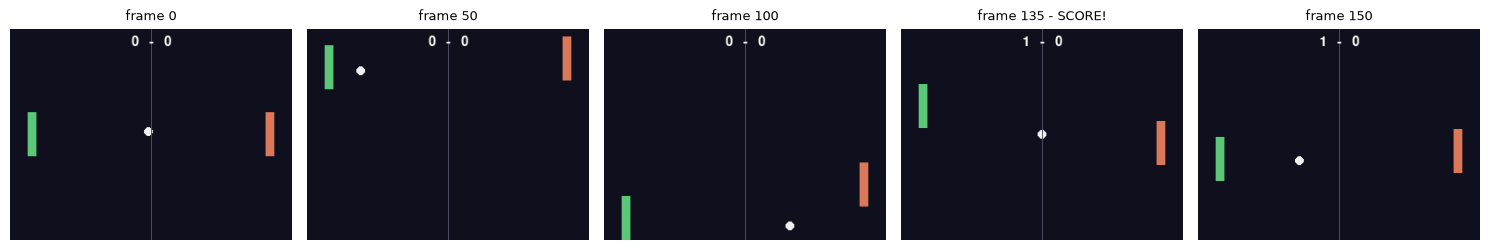

In [3]:
# lets look at the pong snapshots side by side
fig, axes = plt.subplots(1, len(captured), figsize=(3 * len(captured), 3))
for ax, (frame_number, label, pixels) in zip(axes, captured):
    ax.imshow(pixels)
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## game 2: Snake
* the other all-time classic - steer a growing snake around a grid, eat food to grow, dont run into yourself
* the big difference to Pong: instead of pixel-perfect movement, Snake lives on a **grid** - we track the snake as a python `list` of `(x, y)` grid-cell tuples (the first element is the head), and only draw it "zoomed in" by scaling each grid cell up to a fat 20x20 pixel square, so it actually looks like a snake instead of a single pixel
* since we have no real keyboard, we drive the snake with a hardcoded `moves` list (`["right", "up", "up", ...]`) - one direction per frame/tick, exactly the kind of "scripted input" idea from lesson 27
* **growing**: normally, moving the snake means "add a new head, remove the old tail" (so it stays the same length). when the new head lands on the food cell, we skip removing the tail instead - that one extra segment IS the growth!
* **self-collision**: the real rule in every Snake game is "if the new head position is already somewhere else in the snake's body, its game over". we write that check for real below (`if new_head in body[1:]:`), it just never actually triggers here because our scripted move list was chosen to be a nice, safe, non-suicidal little tour of the grid
* food position uses `random.seed(42)` again -> same food spots every time you run this cell

In [4]:
random.seed(42)  # reproducible food positions

GRID_W, GRID_H = 16, 12   # 16x12 grid cells
CELL_SIZE = 20            # each grid cell is drawn as a 20x20 pixel square -> 320x240 screen, same as pong
snake_screen = pygame.display.set_mode((GRID_W * CELL_SIZE, GRID_H * CELL_SIZE))

DIRECTIONS = {"up": (0, -1), "down": (0, 1), "left": (-1, 0), "right": (1, 0)}  # (dx, dy) per grid cell

# the snake body: a list of (x, y) GRID cells, head is always body[0]
snake_body = [(2, 2), (1, 2), (0, 2)]

# our scripted "player input" - one direction per frame, fed in one at a time (no live keyboard needed)
moves = ["right", "up", "up", "right", "right", "down", "down", "right", "right", "down", "right"]


def random_food_position(body):
    """Pick a random grid cell for food that is NOT currently occupied by the snake."""
    while True:
        candidate = (random.randint(0, GRID_W - 1), random.randint(0, GRID_H - 1))
        if candidate not in body:  # dont spawn food on top of the snake itself
            return candidate


food_position = random_food_position(snake_body)
score = 0
game_over = False
snake_snapshots = []  # (frame_number, label, pixel_array)


def draw_snake_frame():
    """Draw the current snake_body + food onto snake_screen, scaled up to CELL_SIZE per grid cell."""
    snake_screen.fill((20, 25, 20))
    # draw the food first, as a red square, so the snake visually "covers" it once eaten
    food_rect = pygame.Rect(food_position[0] * CELL_SIZE, food_position[1] * CELL_SIZE, CELL_SIZE, CELL_SIZE)
    pygame.draw.rect(snake_screen, (220, 70, 70), food_rect)
    # draw every snake segment as its own filled rect - head a bit brighter green than the body, just for clarity
    for index, (grid_x, grid_y) in enumerate(snake_body):
        segment_rect = pygame.Rect(grid_x * CELL_SIZE, grid_y * CELL_SIZE, CELL_SIZE - 2, CELL_SIZE - 2)  # -2 for a thin grid gap
        color = (140, 230, 140) if index == 0 else (60, 170, 70)  # index 0 is always the head
        pygame.draw.rect(snake_screen, color, segment_rect)


draw_snake_frame()
snake_snapshots.append((-1, "start", pygame.surfarray.array3d(snake_screen).swapaxes(0, 1).copy()))

for frame, move in enumerate(moves):
    dx, dy = DIRECTIONS[move]
    old_head = snake_body[0]
    new_head = (old_head[0] + dx, old_head[1] + dy)

    # --- THE self-collision check every real snake game needs (it just never fires with our chosen moves) ---
    # body[1:] means "every segment except the current head" - if the new head lands there, we ran into ourselves
    if new_head in snake_body[1:]:
        game_over = True
        print(f"frame {frame}: game over, snake ran into itself at {new_head}!")
        break

    ate_food = (new_head == food_position)
    if ate_food:
        # GROWING: put the new head on front, but DONT drop the tail -> snake is now one segment longer
        snake_body = [new_head] + snake_body
        score += 1
        food_position = random_food_position(snake_body)  # spawn the next food somewhere fresh
    else:
        # normal move: new head on front, drop the last tail segment -> same total length, just "shifted forward"
        snake_body = [new_head] + snake_body[:-1]

    draw_snake_frame()
    label = f"move {frame}: {move}" + (" - ATE!" if ate_food else "")
    snake_snapshots.append((frame, label, pygame.surfarray.array3d(snake_screen).swapaxes(0, 1).copy()))

print(f"snake finished its scripted route - score (food eaten): {score}, final length: {len(snake_body)}, game_over: {game_over}")

snake finished its scripted route - score (food eaten): 2, final length: 5, game_over: False


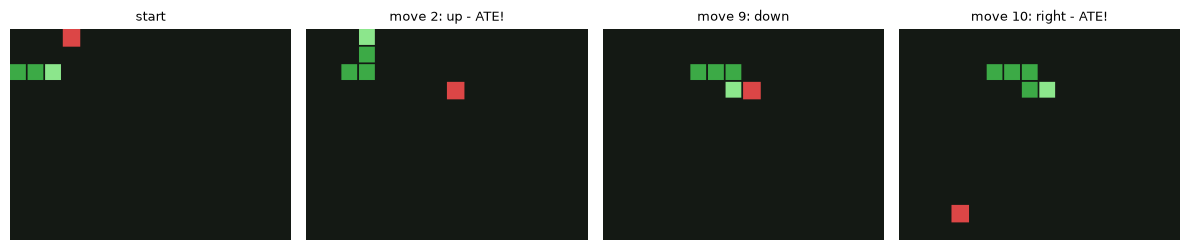

In [5]:
# show a handful of the snake snapshots - start, right after each food pickup, and the very end
interesting_indices = [0, 3, 10, len(snake_snapshots) - 1]  # start, first bite, second bite, final frame
interesting_indices = sorted(set(i for i in interesting_indices if 0 <= i < len(snake_snapshots)))

fig, axes = plt.subplots(1, len(interesting_indices), figsize=(3 * len(interesting_indices), 3))
for ax, snap_index in zip(axes, interesting_indices):
    frame_number, label, pixels = snake_snapshots[snap_index]
    ax.imshow(pixels)
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## game 3: Breakout
* one paddle, one ball, and a wall of bricks up top - bounce the ball into the bricks to clear them, dont let it fall past your paddle
* this one combines ideas from BOTH earlier games: a bouncing ball with wall/paddle collisions (just like Pong), but the "things the ball can hit" are now a whole LIST of `pygame.Rect` bricks that we shrink (by removing hit bricks from the list) as the game goes on
* the paddle AI is the exact same idea as Pong's left paddle: track the ball's x position every frame, clamp to the screen so it cant run off the edge
* collision-with-a-list trick: `pygame.Rect` even has a `.collidelist(list_of_rects)` helper built in - give it a list of rects and it returns the INDEX of the first one it overlaps (or `-1` for none), which is perfect for "which brick did we just hit"
* we run this one until either a handful of bricks are cleared or we hit a frame budget, whichever comes first - no point simulating forever once we've made the point

In [6]:
random.seed(42)  # reproducible ball direction, just like pong

SCREEN_W, SCREEN_H = 320, 240
breakout_screen = pygame.display.set_mode((SCREEN_W, SCREEN_H))

# --- build one row of bricks, centered horizontally ---
BRICK_W, BRICK_H, BRICK_GAP = 34, 14, 6
NUM_BRICKS = 8
row_width = NUM_BRICKS * BRICK_W + (NUM_BRICKS - 1) * BRICK_GAP
row_start_x = (SCREEN_W - row_width) // 2  # center the whole row on screen
bricks = [
    pygame.Rect(row_start_x + col * (BRICK_W + BRICK_GAP), 20, BRICK_W, BRICK_H)
    for col in range(NUM_BRICKS)
]
STARTING_BRICK_COUNT = len(bricks)

PADDLE_W, PADDLE_H = 50, 10
paddle = pygame.Rect((SCREEN_W - PADDLE_W) // 2, SCREEN_H - 20, PADDLE_W, PADDLE_H)
ball = pygame.Rect(SCREEN_W // 2 - 4, 200, 8, 8)
ball_vel = [random.choice([-3, 3]), -4]

score = 0
frame = 0
missed = 0  # how often the ball slipped past the paddle (we just re-serve it, no "lives" system here to keep it simple)
breakout_snapshots = []


def draw_breakout_frame():
    breakout_screen.fill((15, 15, 25))
    for brick in bricks:
        pygame.draw.rect(breakout_screen, (220, 160, 60), brick)
    pygame.draw.rect(breakout_screen, (90, 200, 120), paddle)
    pygame.draw.ellipse(breakout_screen, (240, 240, 240), ball)
    score_text = GAME_FONT.render(f"score: {score}  bricks left: {len(bricks)}", True, (255, 255, 255))
    breakout_screen.blit(score_text, (6, 6))  # top-left corner, out of the way of the bricks/ball


draw_breakout_frame()
breakout_snapshots.append((0, "start", pygame.surfarray.array3d(breakout_screen).swapaxes(0, 1).copy()))

FRAME_BUDGET = 350
BRICKS_TO_CLEAR = 4  # stop once we've knocked out this many bricks, no need to simulate the whole rest of the wall
while (STARTING_BRICK_COUNT - len(bricks)) < BRICKS_TO_CLEAR and frame < FRAME_BUDGET:
    frame += 1
    pygame.event.pump()

    # --- paddle AI: same "just chase the ball's x position" trick as pong's left paddle ---
    if paddle.centerx < ball.centerx:
        paddle.x += min(5, ball.centerx - paddle.centerx)
    elif paddle.centerx > ball.centerx:
        paddle.x -= min(5, paddle.centerx - ball.centerx)
    paddle.clamp_ip(breakout_screen.get_rect())

    ball.x += ball_vel[0]
    ball.y += ball_vel[1]

    if ball.left <= 0 or ball.right >= SCREEN_W:  # bounce off the side walls
        ball_vel[0] *= -1
    if ball.top <= 0:  # bounce off the ceiling
        ball_vel[1] *= -1
    if ball.colliderect(paddle) and ball_vel[1] > 0:  # bounce off the paddle (only if moving downward onto it)
        ball_vel[1] *= -1
    if ball.bottom >= SCREEN_H:  # ball got past the paddle entirely - just re-serve it, no life-loss logic here
        missed += 1
        ball.center = (SCREEN_W // 2, 200)
        ball_vel = [random.choice([-3, 3]), -4]

    # --- brick collision: collidelist() checks the ball against every brick and gives us the FIRST match's index ---
    hit_index = ball.collidelist(bricks)
    if hit_index != -1:
        bricks.pop(hit_index)   # remove that brick from the list entirely - it's destroyed
        ball_vel[1] *= -1       # bounce the ball back
        score += 1

    draw_breakout_frame()
    snapshot_worthy = (frame % 80 == 0) or (hit_index != -1)  # every 80 frames, plus whenever we just broke a brick
    if snapshot_worthy:
        label = f"frame {frame} - {len(bricks)} bricks left"
        breakout_snapshots.append((frame, label, pygame.surfarray.array3d(breakout_screen).swapaxes(0, 1).copy()))

print(f"breakout: ran {frame} frames, score {score}, {len(bricks)}/{STARTING_BRICK_COUNT} bricks left, missed the paddle {missed} times")

breakout: ran 318 frames, score 4, 4/8 bricks left, missed the paddle 0 times


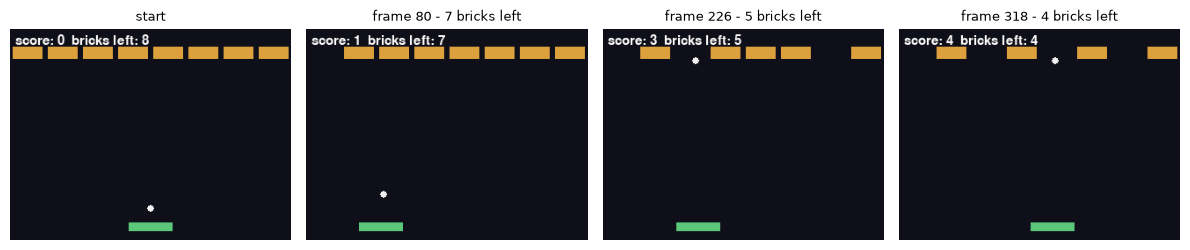

In [7]:
# show a handful of breakout snapshots - you should clearly see fewer bricks in the later ones than at the start
pick = [0, len(breakout_snapshots) // 3, 2 * len(breakout_snapshots) // 3, len(breakout_snapshots) - 1]
pick = sorted(set(pick))

fig, axes = plt.subplots(1, len(pick), figsize=(3 * len(pick), 3))
for ax, snap_index in zip(axes, pick):
    frame_number, label, pixels = breakout_snapshots[snap_index]
    ax.imshow(pixels)
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## quick comparison to other languages
* Pong, Snake and Breakout are basically the universal "first game" exercise - you'll find some version of all three in almost every game-dev tutorial ever written, no matter the language
* in **JavaScript**, these are usually peoples very first browser game ever, built with the `<canvas>` element and `canvas.getContext("2d")` - the drawing calls look different (`ctx.fillRect(...)` instead of `pygame.draw.rect(...)`) but the game loop, collision checks and scoring logic are the same shape
* **Scratch** (MIT's block-based teaching language, often literally a kid's first programming experience) has Pong/Snake/Breakout as some of its most common official starter tutorials - "if touching ball, bounce" blocks instead of `colliderect()`, same idea
* in raw **C with SDL** (the very library pygame wraps!) you'd write almost the exact same structure by hand: an `SDL_Rect` for every paddle/ball/brick, manual AABB collision checks, a `while(running)` loop - pygame is really just "SDL with python's ergonomics on top"
* every proper game ENGINE also uses these three as its "hello world": **Unity**, **Godot** and **GameMaker** all ship an official "make Breakout" tutorial - the concepts (a moving ball, `Rect`/collider overlap checks, removing an object when its "destroyed", incrementing a score variable) translate almost line-for-line, only the exact API calls for drawing and input change from engine to engine

## Exercises
1. add a second row of bricks to the Breakout game (stack it above or below the first row) and confirm bricks from BOTH rows can get destroyed as the ball bounces around
2. make the Pong ball speed up slightly every time it bounces off a paddle (e.g. multiply `ball_vel[0]` by `1.1`) and show, across a few snapshots, that it visibly moves further per frame later in the game than at the start
3. extend the scripted `moves` list for Snake so it eats a 3rd piece of food, and confirm (by printing `len(snake_body)`) that the body list grew correctly after all 3 pickups
4. add simple "miss" detection to Pong: right now we only count official scores - add a `print(...)` that fires the instant the ball's x position goes past a paddle's x position without having bounced off it that frame (hint: you already have this logic, you just need to print something at the same moment `left_score`/`right_score` increments)

In [8]:
# TODO: solve exercise 1 here (add a second row of bricks to breakout, confirm both rows can be destroyed)


# TODO: solve exercise 2 here (pong ball speeds up after every paddle bounce, show it in later snapshots)


# TODO: solve exercise 3 here (extend snake's scripted moves to eat a 3rd food, confirm body length grows)


# TODO: solve exercise 4 here (print a message the instant pong scores a point, i.e. a "miss")

### sample solutions
* try the exercises above yourself first, only look here if you are stuck or want to compare your approach

In [9]:
# sample solution 1 - a second row of bricks, and confirm both rows lose bricks
random.seed(42)
ex_screen = pygame.display.set_mode((320, 240))

BRICK_W, BRICK_H, BRICK_GAP = 34, 14, 6
NUM_BRICKS = 8
row_start_x = (320 - (NUM_BRICKS * BRICK_W + (NUM_BRICKS - 1) * BRICK_GAP)) // 2
# row 1 at y=20 (like before), row 2 stacked right below it at y=20+BRICK_H+BRICK_GAP
ex_bricks = []
for row, y in enumerate([20, 20 + BRICK_H + BRICK_GAP]):
    for col in range(NUM_BRICKS):
        ex_bricks.append(pygame.Rect(row_start_x + col * (BRICK_W + BRICK_GAP), y, BRICK_W, BRICK_H))
ex_starting_count = len(ex_bricks)  # 16 bricks now, 2 rows of 8

ex_paddle = pygame.Rect(135, 220, 50, 10)
ex_ball = pygame.Rect(156, 200, 8, 8)
ex_ball_vel = [random.choice([-3, 3]), -4]
ex_frame = 0
ex_row1_y, ex_row2_y = 20, 20 + BRICK_H + BRICK_GAP
both_rows_hit = False
while not both_rows_hit and ex_frame < 600:  # give it a generous frame budget - top row takes a while to get exposed
    ex_frame += 1
    if ex_paddle.centerx < ex_ball.centerx:
        ex_paddle.x += min(5, ex_ball.centerx - ex_paddle.centerx)
    elif ex_paddle.centerx > ex_ball.centerx:
        ex_paddle.x -= min(5, ex_paddle.centerx - ex_ball.centerx)
    ex_paddle.clamp_ip(ex_screen.get_rect())
    ex_ball.x += ex_ball_vel[0]
    ex_ball.y += ex_ball_vel[1]
    if ex_ball.left <= 0 or ex_ball.right >= 320:
        ex_ball_vel[0] *= -1
    if ex_ball.top <= 0:
        ex_ball_vel[1] *= -1
    if ex_ball.colliderect(ex_paddle) and ex_ball_vel[1] > 0:
        ex_ball_vel[1] *= -1
    if ex_ball.bottom >= 240:
        ex_ball.center = (160, 200)
        ex_ball_vel = [random.choice([-3, 3]), -4]
    hit = ex_ball.collidelist(ex_bricks)
    if hit != -1:
        ex_bricks.pop(hit)
        ex_ball_vel[1] *= -1

    remaining_row1 = sum(1 for b in ex_bricks if b.y == ex_row1_y)
    remaining_row2 = sum(1 for b in ex_bricks if b.y == ex_row2_y)
    both_rows_hit = remaining_row1 < NUM_BRICKS and remaining_row2 < NUM_BRICKS  # stop once BOTH rows lost >=1 brick

print(f"exercise 1: started with {ex_starting_count} bricks (2 rows of {NUM_BRICKS}), ran {ex_frame} frames")
print(f"row 1 remaining: {remaining_row1}/{NUM_BRICKS}, row 2 remaining: {remaining_row2}/{NUM_BRICKS} -> both rows lost bricks: {both_rows_hit}")


# sample solution 2 - pong ball speeding up after every paddle bounce
random.seed(42)
ex2_screen = pygame.display.set_mode((320, 240))
ex2_left = pygame.Rect(20, 95, 10, 50)
ex2_right = pygame.Rect(290, 95, 10, 50)
ex2_ball = pygame.Rect(155, 115, 10, 10)
ex2_vel = [random.choice([-3, 3]), random.choice([-3, -2, 2, 3])]
ex2_speeds = []  # track abs(dx) over time so we can PROVE it increases
ex2_target_y = ex2_right.centery
for f in range(160):
    if ex2_left.centery < ex2_ball.centery:
        ex2_left.y += min(4, ex2_ball.centery - ex2_left.centery)
    elif ex2_left.centery > ex2_ball.centery:
        ex2_left.y -= min(4, ex2_left.centery - ex2_ball.centery)
    ex2_left.clamp_ip(ex2_screen.get_rect())
    if f % 6 == 0:
        ex2_target_y = ex2_ball.centery
    if ex2_right.centery < ex2_target_y:
        ex2_right.y += min(3, ex2_target_y - ex2_right.centery)
    elif ex2_right.centery > ex2_target_y:
        ex2_right.y -= min(3, ex2_right.centery - ex2_target_y)
    ex2_right.clamp_ip(ex2_screen.get_rect())
    ex2_ball.x += ex2_vel[0]
    ex2_ball.y += ex2_vel[1]
    if ex2_ball.top <= 0 or ex2_ball.bottom >= 240:
        ex2_vel[1] *= -1
    if ex2_ball.colliderect(ex2_left) and ex2_vel[0] < 0:
        ex2_vel[0] *= -1.1  # <-- the actual exercise: speed up by 10% on every paddle bounce
    if ex2_ball.colliderect(ex2_right) and ex2_vel[0] > 0:
        ex2_vel[0] *= -1.1
    if ex2_ball.left <= 0 or ex2_ball.right >= 320:  # (no scoring here, just measuring speed for the exercise)
        ex2_ball.center = (160, 120)
        ex2_vel = [3, random.choice([-3, -2, 2, 3])]
    ex2_speeds.append(abs(ex2_vel[0]))
print("exercise 2: ball horizontal speed over time (should trend upward after each bounce):")
print("  first 5 frames:", [round(s, 2) for s in ex2_speeds[:5]])
print("  last 5 frames: ", [round(s, 2) for s in ex2_speeds[-5:]])


# sample solution 3 - extend snake's moves to eat a 3rd food, confirm growth
random.seed(42)
ex3_body = [(2, 2), (1, 2), (0, 2)]
def ex3_random_food(body):
    while True:
        pos = (random.randint(0, 15), random.randint(0, 11))
        if pos not in body:
            return pos
ex3_food = ex3_random_food(ex3_body)
ex3_moves = ["right", "up", "up", "right", "right", "down", "down", "right", "right", "down", "right",
             "right", "right", "down", "down",
             "left", "left", "left", "left", "left", "left", "left",
             "down", "down", "down", "down", "down"]  # extra moves tacked onto the original list, to reach a 3rd food
ex3_lengths_after_eating = []
for move in ex3_moves:
    dx, dy = {"up": (0, -1), "down": (0, 1), "left": (-1, 0), "right": (1, 0)}[move]
    new_head = (ex3_body[0][0] + dx, ex3_body[0][1] + dy)
    if new_head in ex3_body[1:]:
        break  # would be game over - stop here (shouldnt happen with this scripted route)
    ate = (new_head == ex3_food)
    ex3_body = [new_head] + ex3_body if ate else [new_head] + ex3_body[:-1]
    if ate:
        ex3_food = ex3_random_food(ex3_body)
        ex3_lengths_after_eating.append(len(ex3_body))
print(f"exercise 3: body length after each food eaten: {ex3_lengths_after_eating} (started at length 3)")
print(f"total food eaten: {len(ex3_lengths_after_eating)}, final body length: {len(ex3_body)}")


# sample solution 4 - print a message the instant a "miss" (score) happens in pong
random.seed(42)
ex4_screen = pygame.display.set_mode((320, 240))
ex4_left = pygame.Rect(20, 95, 10, 50)
ex4_right = pygame.Rect(290, 95, 10, 50)
ex4_ball = pygame.Rect(155, 115, 10, 10)
ex4_vel = [random.choice([-3, 3]), random.choice([-3, -2, 2, 3])]
ex4_left_score = ex4_right_score = 0
ex4_target_y = ex4_right.centery
for f in range(200):
    if ex4_left.centery < ex4_ball.centery:
        ex4_left.y += min(4, ex4_ball.centery - ex4_left.centery)
    elif ex4_left.centery > ex4_ball.centery:
        ex4_left.y -= min(4, ex4_left.centery - ex4_ball.centery)
    ex4_left.clamp_ip(ex4_screen.get_rect())
    if f % 6 == 0:
        ex4_target_y = ex4_ball.centery
    if ex4_right.centery < ex4_target_y:
        ex4_right.y += min(3, ex4_target_y - ex4_right.centery)
    elif ex4_right.centery > ex4_target_y:
        ex4_right.y -= min(3, ex4_right.centery - ex4_target_y)
    ex4_right.clamp_ip(ex4_screen.get_rect())
    ex4_ball.x += ex4_vel[0]
    ex4_ball.y += ex4_vel[1]
    if ex4_ball.top <= 0 or ex4_ball.bottom >= 240:
        ex4_vel[1] *= -1
    if ex4_ball.colliderect(ex4_left) and ex4_vel[0] < 0:
        ex4_vel[0] *= -1
        ex4_vel[1] += random.choice([-1, 0, 1])  # same little "spin" as the main game, so this plays out identically
    if ex4_ball.colliderect(ex4_right) and ex4_vel[0] > 0:
        ex4_vel[0] *= -1
        ex4_vel[1] += random.choice([-1, 0, 1])
    # this IS the "miss" moment: the ball's x went past a paddle's x without bouncing off it - print right here
    if ex4_ball.left <= 0:
        ex4_right_score += 1
        print(f"exercise 4: MISS! frame {f}, ball got past the LEFT paddle, right side now scores {ex4_right_score}")
        ex4_ball.center = (160, 120)
        ex4_vel = [3, random.choice([-3, -2, 2, 3])]
    if ex4_ball.right >= 320:
        ex4_left_score += 1
        print(f"exercise 4: MISS! frame {f}, ball got past the RIGHT paddle, left side now scores {ex4_left_score}")
        ex4_ball.center = (160, 120)
        ex4_vel = [-3, random.choice([-3, -2, 2, 3])]

exercise 1: started with 16 bricks (2 rows of 8), ran 546 frames
row 1 remaining: 7/8, row 2 remaining: 2/8 -> both rows lost bricks: True
exercise 2: ball horizontal speed over time (should trend upward after each bounce):
  first 5 frames: [3, 3, 3, 3, 3]
  last 5 frames:  [3.63, 3.63, 3.63, 3.63, 3.63]
exercise 3: body length after each food eaten: [4, 5, 6] (started at length 3)
total food eaten: 3, final body length: 6
exercise 4: MISS! frame 135, ball got past the RIGHT paddle, left side now scores 1


* congratulation you finished this lesson

## what we learned
* how to combine every building block from lesson 27 (drawing, the game loop, `Rect.colliderect()`, simulated input) into three complete, playable classic games
* **Pong**: two AI-controlled paddles, wall bounce logic, paddle collision, and a score-then-reset pattern
* **Snake**: representing a game object as a list of `(x, y)` grid cells, growing a list by NOT dropping the tail on a "hit", and the real self-collision check (`if new_head in snake_body[1:]:`)
* **Breakout**: `Rect.collidelist()` to check a moving object against a whole LIST of targets at once, and removing entries from that list as they get destroyed
* that a "scripted AI" (a paddle that just chases a target position, a hardcoded list of moves) is a perfectly good stand-in for live player input when you need a game to run automatically and reproducibly (`random.seed(...)`) - the exact same technique real game studios use for automated testing
* that Pong/Snake/Breakout are the universal "first game" across basically every language and engine - the drawing/input API changes, the underlying game loop and collision logic barely does
* next up: we start building towards a real, persistent RPG, combining these same ideas (game loop, collision, scripted-then-later-real input) into something much bigger